# Laser-dot image-plane trajectory (paper figure)

Paper reference: §3.2 (System Model) — Figure `fig:laser_spot_path`.

Renders the laser dot's path across the image plane as target distance
increases. The dot converges toward a fixed vanishing point as
distance $\to \infty$ and diverges from it at close range. Dot size is
proportional to the apparent laser spot in pixels, reflecting that
both position and size encode depth — though FishSense Lite uses only
position.

**Output:** `figures/laser_spot_path.pdf` (paper Figure 3).

In [38]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import ConnectionPatch, Ellipse, Circle

from fishsense_imwut.constants import (
    FOCAL_LENGTH_PX,
    IMAGE_HEIGHT,
    IMAGE_WIDTH,
    LASER_DIAMETER_M,
)
from fishsense_imwut.figures import save_paper_figure

## Setup

In [39]:
camera_intrinsics = np.array([
    [FOCAL_LENGTH_PX, 0, IMAGE_WIDTH / 2],
    [0, FOCAL_LENGTH_PX, IMAGE_HEIGHT / 2],
    [0, 0, 1],
])
camera_intrinsics

array([[2.850e+03, 0.000e+00, 2.007e+03],
       [0.000e+00, 2.850e+03, 1.508e+03],
       [0.000e+00, 0.000e+00, 1.000e+00]])

In [40]:
laser_position = np.array([-0.04, -0.11, 0])
laser_direction = np.array([1e-10, 1e-10, 1])

laser_position, laser_direction

(array([-0.04, -0.11,  0.  ]), array([1.e-10, 1.e-10, 1.e+00]))

**Ground-truth laser pose** — 4 cm lateral and 11 cm vertical offset from the focal point, pointing essentially along the optical axis. Tiny $x/y$ components in `laser_direction` avoid exact collinearity with the optical axis (which would make depth unobservable).

## Log-spaced sample path

180 log-spaced distances from 0.10 m to 500 m, plus forced anchors at
0.3 / 0.8 / 2 / 3 / 4 / 5 m. Dots at $\le 5$ m render on the main canvas;
dots beyond 5 m appear only in the circular inset to show convergence
on the vanishing point.

In [41]:
min_z, max_z, n_log = 0.10, 500.0, 180
forced_z = np.array([0.3, 0.8, 2.0, 3.0, 4.0, 5.0])
all_z = np.sort(np.unique(np.concatenate([
    np.geomspace(min_z, max_z, n_log),
    forced_z,
])))
all_z.shape

(186,)

In [42]:
all_p       = laser_position[:, None] + all_z[None, :] * laser_direction[:, None]
all_p_left  = all_p.copy(); all_p_left[0, :]  -= LASER_DIAMETER_M / 2
all_p_right = all_p.copy(); all_p_right[0, :] += LASER_DIAMETER_M / 2
all_p_up    = all_p.copy(); all_p_up[1, :]    += LASER_DIAMETER_M / 2
all_p_down  = all_p.copy(); all_p_down[1, :]  -= LASER_DIAMETER_M / 2

all_s       = camera_intrinsics @ (all_p       / all_p[2, :])
all_s_left  = camera_intrinsics @ (all_p_left  / all_p_left[2, :])
all_s_right = camera_intrinsics @ (all_p_right / all_p_right[2, :])
all_s_up    = camera_intrinsics @ (all_p_up    / all_p_up[2, :])
all_s_down  = camera_intrinsics @ (all_p_down  / all_p_down[2, :])

Back-projects the laser disk's four cardinal points at each distance so each dot in the figure is drawn as an ellipse whose pixel extent matches the apparent spot size.

In [43]:
dots  = []
trail = []
for j in range(all_z.shape[0]):
    cx, cy = all_s[0, j], all_s[1, j]
    z = all_z[j]
    w = all_s_right[0, j] - all_s_left[0, j]
    h = all_s_up[1, j]    - all_s_down[1, j]
    if not (np.isfinite(cx) and np.isfinite(cy) and np.isfinite(w) and np.isfinite(h)):
        continue
    if w <= 0 or h <= 0:
        continue
    entry = (cx, cy, z, w, h)
    (dots if z <= 5.0 else trail).append(entry)

if not dots:
    raise RuntimeError('No valid dot centers found.')

len(dots), len(trail)

(89, 97)

In [44]:
visible = [d for d in dots if 0 <= d[0] <= IMAGE_WIDTH and 0 <= d[1] <= IMAGE_HEIGHT]
far_dots = [d for d in visible if 4.0 <= d[2] <= 5.0]

label_targets = (2, 3, 5)
label_anchors = {}
for target in label_targets:
    for cx, cy, z, w, h in dots:
        if abs(z - target) < 1e-9:
            label_anchors[target] = (cx, cy)
            break

ab_targets = {'A': 0.3, 'B': 0.8}
ab_anchors = {}
for name, target in ab_targets.items():
    for cx, cy, z, w, h in dots:
        if abs(z - target) < 1e-9:
            ab_anchors[name] = (cx, cy, target)
            break

label_anchors, ab_anchors

({2: (np.float64(1950.000000285), np.float64(1351.250000285)),
  3: (np.float64(1969.000000285), np.float64(1403.500000285)),
  5: (np.float64(1984.200000285), np.float64(1445.300000285))},
 {'A': (np.float64(1627.0000002850002), np.float64(463.00000028499994), 0.3),
  'B': (np.float64(1864.500000285), np.float64(1116.1250002850002), 0.8)})

In [45]:
vp_x, vp_y = IMAGE_WIDTH / 2, IMAGE_HEIGHT / 2
anchor_xs = [d[0] for d in far_dots] + [vp_x] + [a[0] for a in label_anchors.values()]
anchor_ys = [d[1] for d in far_dots] + [vp_y] + [a[1] for a in label_anchors.values()]

center_x = (min(anchor_xs) + max(anchor_xs)) / 2
center_y = (min(anchor_ys) + max(anchor_ys)) / 2
half_span = max(
    max(anchor_xs) - min(anchor_xs),
    max(anchor_ys) - min(anchor_ys),
) / 2
radius = half_span + 120   # padding so labels fit on the left

x1, x2 = center_x - radius, center_x + radius
y1, y2 = center_y - radius, center_y + radius

The ROI is a square around the vanishing point, far dots, and labeled anchors, so the circular inset is a true circle when `aspect='equal'`.

## Figure

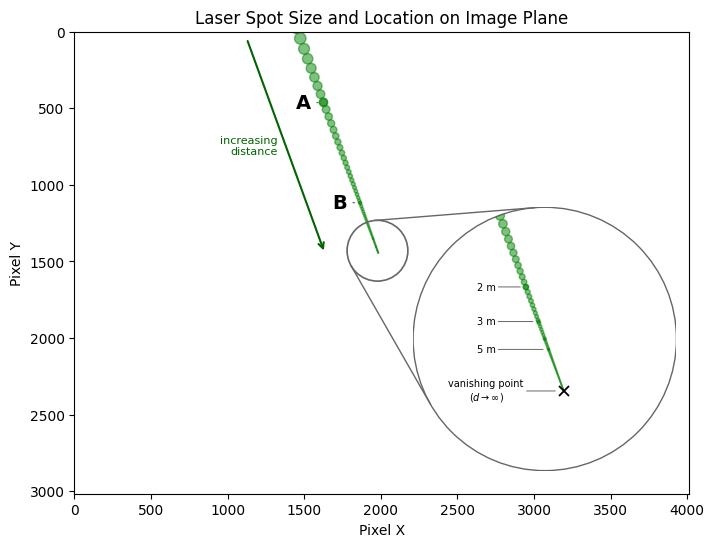

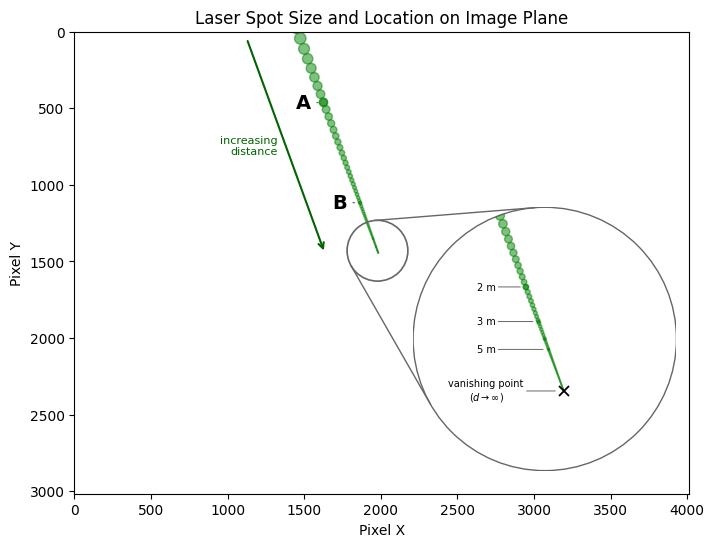

In [46]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.set_xlim(0, IMAGE_WIDTH)
ax.set_ylim(IMAGE_HEIGHT, 0)
ax.set_aspect('equal')
ax.set_xlabel('Pixel X')
ax.set_ylabel('Pixel Y')
ax.set_title('Laser Spot Size and Location on Image Plane')

# Inset placed bottom-right so its circle clears the ROI circle.
axins = ax.inset_axes([0.55, 0.05, 0.43, 0.57])
axins.set_xlim(x1, x2)
axins.set_ylim(y2, y1)
axins.set_aspect('equal')
axins.set_xticks([])
axins.set_yticks([])
axins.patch.set_visible(False)
for spine in axins.spines.values():
    spine.set_visible(False)

clip_circle = Circle(
    (0.5, 0.5), 0.5, transform=axins.transAxes,
    facecolor='white', edgecolor='0.4', linewidth=1.0, zorder=-10,
)
axins.add_patch(clip_circle)

def _add_clipped_patch(owner, patch):
    owner.add_patch(patch)
    patch.set_clip_path(clip_circle)
    return patch

for cx, cy, z, w, h in dots:
    ax.add_patch(Ellipse((cx, cy), w, h, edgecolor='g', facecolor='g', alpha=0.5))
    _add_clipped_patch(axins, Ellipse((cx, cy), w, h, edgecolor='g', facecolor='g', alpha=0.5))

for cx, cy, z, w, h in trail:
    if not (x1 <= cx <= x2 and y1 <= cy <= y2):
        continue
    _add_clipped_patch(axins, Ellipse((cx, cy), w, h, edgecolor='g', facecolor='g', alpha=0.5))

# Leader-line distance labels on the inset.
label_x = x1 + 110
labels_in_inset = {t: a for t, a in label_anchors.items()
                   if x1 <= a[0] <= x2 and y1 <= a[1] <= y2}
for z_int in sorted(labels_in_inset):
    cx, cy = labels_in_inset[z_int]
    ly = max(y1 + 25, min(y2 - 25, cy))
    annot = axins.annotate(
        f'{z_int} m',
        xy=(cx, cy), xytext=(label_x, ly),
        fontsize=7, color='black', ha='center', va='center',
        arrowprops=dict(arrowstyle='-', color='0.3', lw=0.6, shrinkA=0, shrinkB=4),
    )
    annot.set_clip_path(clip_circle)
    if annot.arrow_patch is not None:
        annot.arrow_patch.set_clip_path(clip_circle)

vp_marker, = axins.plot(
    vp_x, vp_y, marker='x', color='black',
    markersize=7, markeredgewidth=1.3, zorder=5,
)
vp_marker.set_clip_path(clip_circle)
vp_label_y = max(y1 + 25, min(y2 - 25, vp_y))
vp_annot = axins.annotate(
    'vanishing point\n$(d \\rightarrow \\infty)$',
    xy=(vp_x, vp_y), xytext=(label_x, vp_label_y),
    fontsize=7, color='black', ha='center', va='center',
    arrowprops=dict(arrowstyle='-', color='0.3', lw=0.6, shrinkA=0, shrinkB=6),
)
vp_annot.set_clip_path(clip_circle)
if vp_annot.arrow_patch is not None:
    vp_annot.arrow_patch.set_clip_path(clip_circle)

# ROI indicator on the main axes.
ax.add_patch(Circle((center_x, center_y), radius, fill=False, ec='0.4', lw=1.2))

# External-tangent connection lines between the two circles.
fig.canvas.draw()
roi_c = np.array(ax.transData.transform((center_x, center_y)))
roi_r_disp = abs(ax.transData.transform((center_x + radius, center_y))[0] - roi_c[0])
ins_c = np.array(axins.transAxes.transform((0.5, 0.5)))
ins_r_disp = abs(axins.transAxes.transform((1.0, 0.5))[0] - ins_c[0])

delta = ins_c - roi_c
d_disp = np.linalg.norm(delta)
u = delta / d_disp
v = np.array([-u[1], u[0]])
a_coef = (roi_r_disp - ins_r_disp) / d_disp
b_coef = np.sqrt(max(0.0, 1.0 - a_coef ** 2))
n_upper = a_coef * u + b_coef * v
n_lower = a_coef * u - b_coef * v

for n in (n_upper, n_lower):
    roi_tp_disp = roi_c + roi_r_disp * n
    ins_tp_disp = ins_c + ins_r_disp * n
    roi_tp_data = ax.transData.inverted().transform(roi_tp_disp)
    ins_tp_ax   = axins.transAxes.inverted().transform(ins_tp_disp)
    fig.add_artist(ConnectionPatch(
        xyA=tuple(ins_tp_ax), coordsA=axins.transAxes,
        xyB=tuple(roi_tp_data), coordsB=ax.transData,
        color='0.4', lw=1.0, clip_on=False,
    ))

# "Increasing distance" arrow along the dot path, offset left.
by_z = sorted(visible, key=lambda d: d[2])
near_cx, near_cy = by_z[0][0], by_z[0][1]
far_cx,  far_cy  = by_z[-1][0], by_z[-1][1]
offset_x = 350
tail_x = max(120, near_cx - offset_x)
tail_y = near_cy
head_x = max(120, far_cx  - offset_x)
head_y = far_cy
ax.annotate(
    '', xy=(head_x, head_y), xytext=(tail_x, tail_y),
    arrowprops=dict(arrowstyle='->', color='darkgreen', lw=1.5),
)
ax.text(
    (tail_x + head_x) / 2 - 50, (tail_y + head_y) / 2,
    'increasing\ndistance',
    fontsize=8, color='darkgreen', ha='right', va='center',
)

# A and B callouts on the main axes (paper text references).
label_dx = -130
for name, (cx, cy, z) in ab_anchors.items():
    ax.annotate(
        name,
        xy=(cx, cy), xytext=(cx + label_dx, cy),
        fontsize=14, color='black', ha='center', va='center',
        fontweight='bold',
        arrowprops=dict(arrowstyle='-', color='0.3', lw=0.8, shrinkA=2, shrinkB=4),
    )

save_paper_figure(fig, 'laser_spot_path.pdf', dpi=300)
fig